# Diabetic Retinopathy Detection
## Image Processing + Custom CNN Approach

**3-Class Classification:** No DR (0) | Mild DR (1-2) | Severe DR (3-4)

**Pipeline:**
1. Green Channel Extraction
2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
3. Gaussian Blur + Morphological Operations
4. Custom CNN Training & Evaluation

---
## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from itertools import cycle
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.21.0
GPU available: []


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 3
LEARNING_RATE = 1e-4

DATASET_DIR = r'Dataset'
IMAGE_DIR = os.path.join(DATASET_DIR, 'train', 'train')
LABELS_CSV = os.path.join(DATASET_DIR, 'trainLabels.csv')

CLASS_NAMES = ['No DR', 'Mild DR', 'Severe DR']

LABEL_MAP = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}

---
## 2. Load & Explore Dataset

In [3]:
df = pd.read_csv(LABELS_CSV)
df['class'] = df['level'].map(LABEL_MAP)
df['filepath'] = df['image'].apply(lambda x: os.path.join(IMAGE_DIR, x + '.jpeg'))

df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)

print(f'Total valid images: {len(df)}')
print(f'\nOriginal label distribution:')
print(df['level'].value_counts().sort_index())
print(f'\n3-Class distribution:')
print(df['class'].value_counts().sort_index())

Total valid images: 35126

Original label distribution:
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

3-Class distribution:
class
0    25810
1     7735
2     1581
Name: count, dtype: int64


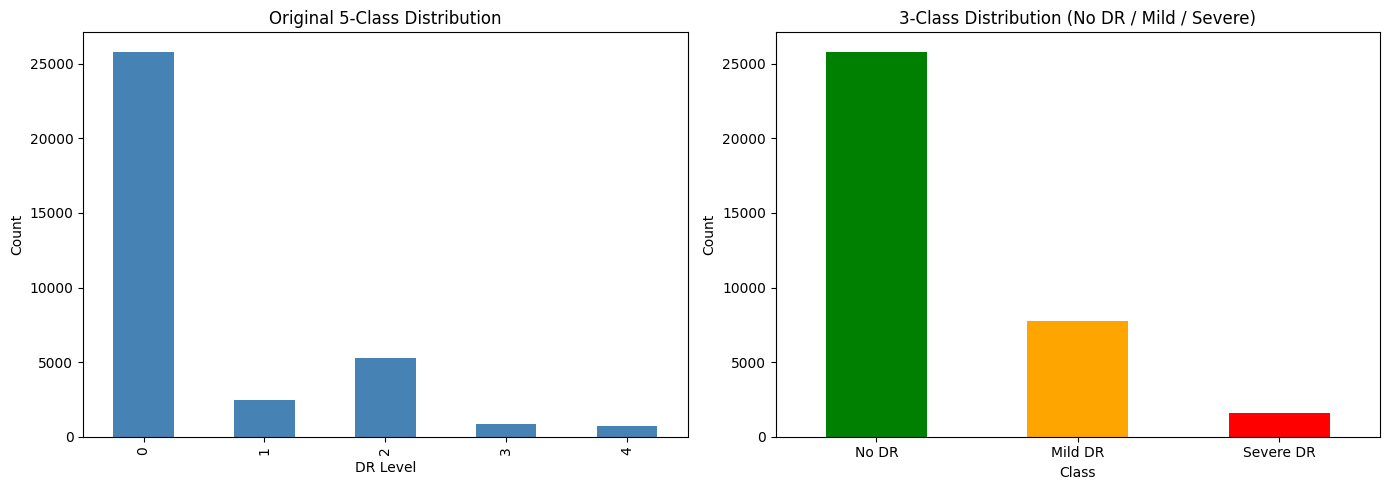

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['level'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original 5-Class Distribution')
axes[0].set_xlabel('DR Level')
axes[0].set_ylabel('Count')

df['class'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('3-Class Distribution (No DR / Mild / Severe)')
axes[1].set_xlabel('Class')
axes[1].set_xticklabels(CLASS_NAMES, rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 3. Image Preprocessing Pipeline

### 3.1 Green Channel Extraction
The green channel of RGB retinal images provides the best contrast for blood vessels and lesions.

In [9]:
def extract_green_channel(image):
    green = image[:, :, 1]  # BGR image — index 1 is the green channel
    return green

def apply_clahe(image, clip_limit=2.0, grid_size=(8, 8)):
    # FIXED: removed the BGR→GRAY conversion — image is already grayscale here
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    return clahe.apply(image)

def apply_gaussian_blur(image, kernel_size=(5, 5)):
    return cv2.GaussianBlur(image, kernel_size, 0)

def apply_morphological_ops(image, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    tophat = cv2.morphologyEx(image, cv2.MORPH_TOPHAT, kernel)
    blackhat = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)
    enhanced = cv2.add(image, tophat)
    enhanced = cv2.subtract(enhanced, blackhat)
    return enhanced

def preprocess_image(image_path, target_size=IMG_SIZE):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.resize(img, (target_size, target_size))
    green = extract_green_channel(img)
    clahe_img = apply_clahe(green)
    blurred = apply_gaussian_blur(clahe_img)
    enhanced = apply_morphological_ops(blurred)
    enhanced = np.stack([enhanced] * 3, axis=-1)
    enhanced = enhanced.astype(np.float32) / 255.0
    return enhanced

### 3.2 Visualize Preprocessing Steps

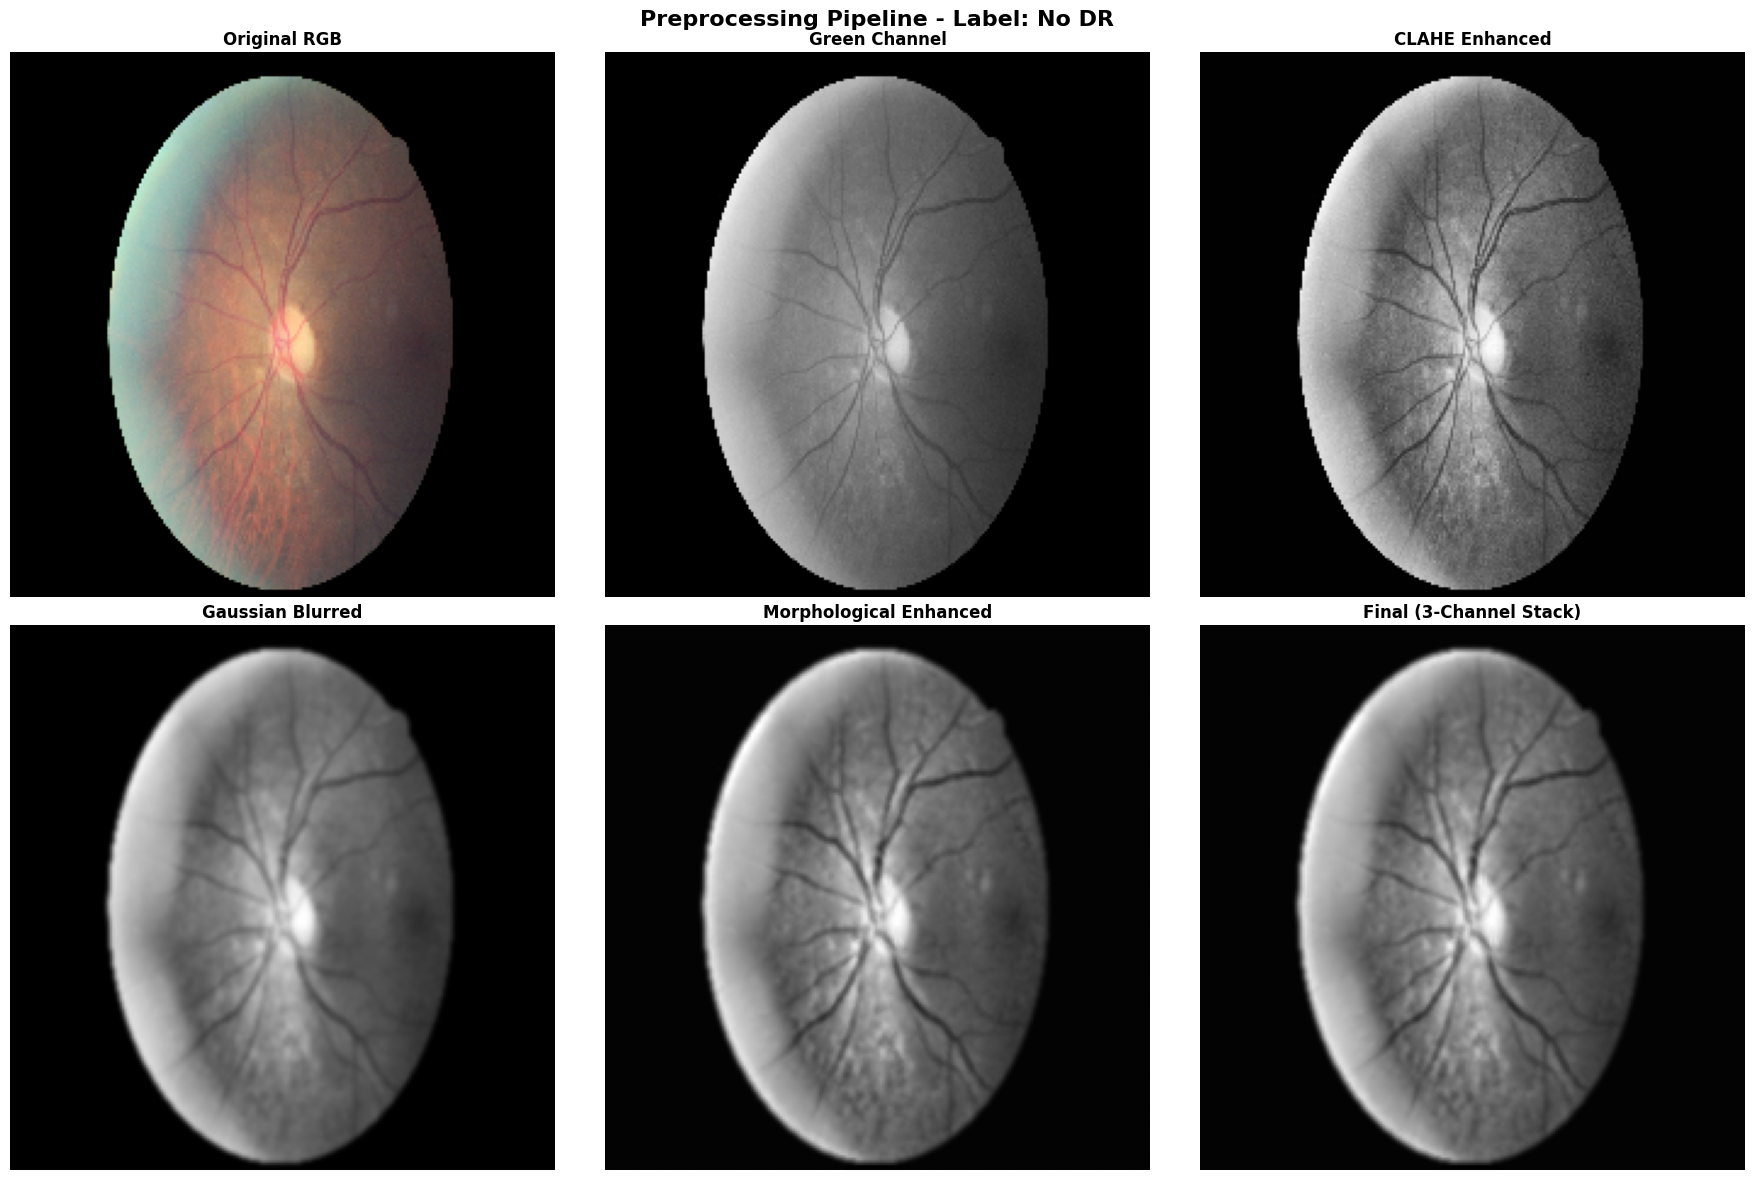

In [10]:
sample_row = df.iloc[0]
sample_img = cv2.imread(sample_row['filepath'])
sample_img = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

green = extract_green_channel(sample_img)
clahe_img = apply_clahe(green)
blurred = apply_gaussian_blur(clahe_img)
enhanced = apply_morphological_ops(blurred)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
titles = ['Original RGB', 'Green Channel', 'CLAHE Enhanced',
          'Gaussian Blurred', 'Morphological Enhanced', 'Final (3-Channel Stack)']
images = [sample_rgb, green, clahe_img, blurred, enhanced, np.stack([enhanced]*3, axis=-1)]
cmaps = [None, 'gray', 'gray', 'gray', 'gray', None]

for idx, (ax, title, img, cmap) in enumerate(zip(axes.flat, titles, images, cmaps)):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Preprocessing Pipeline - Label: {CLASS_NAMES[sample_row["class"]]}',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Show Samples from Each Class

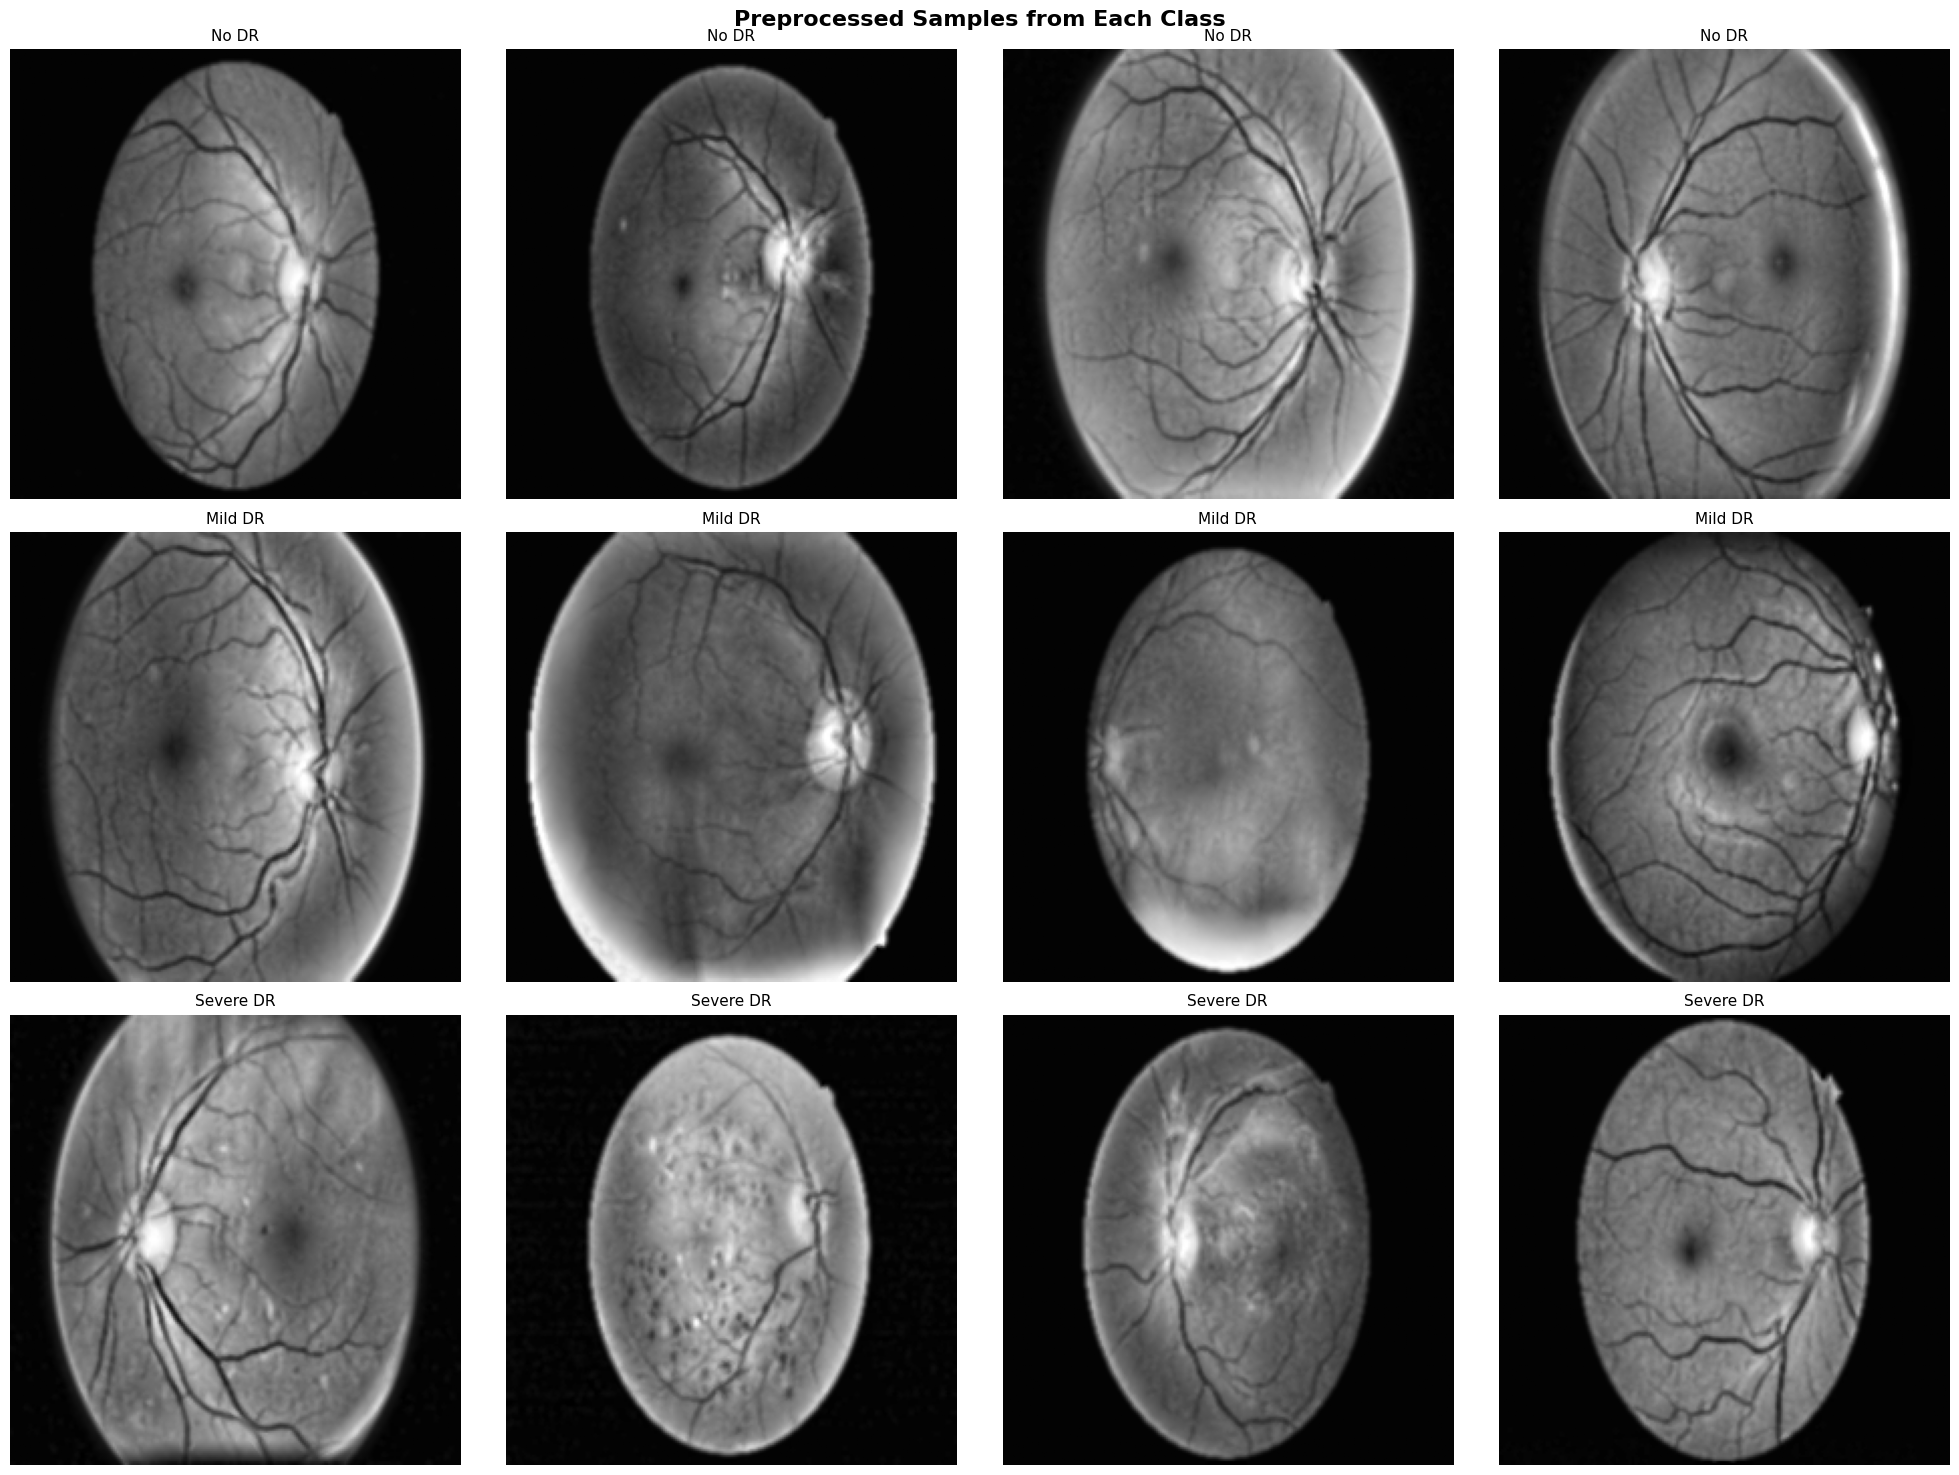

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for cls_idx in range(3):
    class_df = df[df['class'] == cls_idx].sample(4, random_state=42)
    for col_idx, (_, row) in enumerate(class_df.iterrows()):
        processed = preprocess_image(row['filepath'])
        axes[cls_idx, col_idx].imshow(processed)
        axes[cls_idx, col_idx].set_title(f'{CLASS_NAMES[cls_idx]}', fontsize=11)
        axes[cls_idx, col_idx].axis('off')

plt.suptitle('Preprocessed Samples from Each Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Loading & Splitting

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'\nTrain class distribution:\n{train_df["class"].value_counts().sort_index()}')
print(f'\nVal class distribution:\n{val_df["class"].value_counts().sort_index()}')
print(f'\nTest class distribution:\n{test_df["class"].value_counts().sort_index()}')

Train: 24588 | Val: 5269 | Test: 5269

Train class distribution:
class
0    18067
1     5414
2     1107
Name: count, dtype: int64

Val class distribution:
class
0    3871
1    1161
2     237
Name: count, dtype: int64

Test class distribution:
class
0    3872
1    1160
2     237
Name: count, dtype: int64


### 4.1 Batch Data Generator with On-the-Fly Preprocessing

In [13]:
class DRDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, img_size=IMG_SIZE,
                 augment=False, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.dataframe))
        if self.shuffle:
            np.random.shuffle(self.indices)

        # FIXED: use Keras augmentation layers instead of deprecated ImageDataGenerator
        if augment:
            self.augmentor = tf.keras.Sequential([
                layers.RandomFlip('horizontal_and_vertical'),
                layers.RandomRotation(30 / 360),
                layers.RandomZoom(0.2),
            ])

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = np.zeros((len(batch_indices), self.img_size, self.img_size, 3), dtype=np.float32)
        batch_y = np.zeros(len(batch_indices), dtype=np.int32)

        for i, bi in enumerate(batch_indices):
            row = self.dataframe.iloc[bi]
            processed = preprocess_image(row['filepath'], self.img_size)
            if processed is not None:
                batch_x[i] = processed
            else:
                # FIXED: warn instead of silently using zeros
                print(f'Warning: failed to load {row["filepath"]}')
            batch_y[i] = row['class']

        # FIXED: augment as a batch on normalized data (layers work on [0,1])
        if self.augment:
            batch_x = self.augmentor(batch_x, training=True).numpy()

        return batch_x, to_categorical(batch_y, num_classes=NUM_CLASSES)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [14]:
train_gen = DRDataGenerator(train_df, batch_size=BATCH_SIZE, augment=True, shuffle=True)
val_gen = DRDataGenerator(val_df, batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_gen = DRDataGenerator(test_df, batch_size=BATCH_SIZE, augment=False, shuffle=False)

print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}')

Train batches: 769 | Val batches: 165 | Test batches: 165


---
## 5. Custom CNN Architecture

In [15]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [16]:
model = build_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,442,851 (5.50 MB)

 Trainable params: 1,439,395 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

---
## 6. Training

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['class']),
    y=train_df['class']
)

---
## 7. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Evaluation on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

In [ ]:
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_df['class'].values[:len(y_pred)]

In [ ]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

### 8.1 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 8.2 ROC Curves (One-vs-Rest)

In [ ]:
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'orange', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Inference on Single Image

In [ ]:
def predict_dr(image_path, model):
    processed = preprocess_image(image_path)
    if processed is None:
        print('Error: Could not read image')
        return

    input_img = np.expand_dims(processed, axis=0)
    prediction = model.predict(input_img, verbose=0)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx]

    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(processed)
    axes[1].set_title(f'Preprocessed', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle(f'Prediction: {CLASS_NAMES[class_idx]} ({confidence*100:.1f}%)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nClass Probabilities:')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name}: {prediction[0][i]*100:.2f}%')

    return CLASS_NAMES[class_idx], confidence

In [ ]:
sample = df[df['class'] == 2].iloc[0]
predict_dr(sample['filepath'], model)

---
## 10. Save Model

In [18]:
model.save('dr_detection_model.keras')
print('Model saved as dr_detection_model.keras')

Model saved as dr_detection_model.keras


---
## Summary

| Component | Details |
|---|---|
| **Preprocessing** | Green Channel -> CLAHE -> Gaussian Blur -> Morphological Enhancement |
| **Model** | Custom CNN (4 conv blocks + 2 dense layers) |
| **Classes** | No DR (0) / Mild DR (1-2) / Severe DR (3-4) |
| **Training** | Adam optimizer, class weights, early stopping, LR reduction |
| **Augmentation** | Rotation, zoom, horizontal/vertical flips |